# **🤖 Lesson 5.1: Foundations of Generative AI Systems**

**Overview: Bridging Theory and Build**

Today’s session is designed as a continuous "Spiral": we will introduce a concept on the slides and immediately move into this notebook to build it. We aren't just looking at how AI works in a "black box"—we are engineering the systems that make AI useful, private, and accessible.

We will move from the high-level architecture of Transformers and Diffusion to the ground-level reality of APIs, Local Hosting, and Mobile Deployment.

**High-Level Learning Objectives**

By the end of this integrated session, you will be able to:

*   Architect Reactive UIs: Connect to industrial-grade inference engines (Groq) and launch a functional web interface using Gradio.

*   Manage Model Persistence: Master the lifecycle of an AI model—specifically how to download, save to Google Drive, and reload models for "offline" or private use.

*   Deploy Multimodal Pipelines: Configure and run a Stable Diffusion engine to transform text prompts into visual assets.

*   Engineer End-to-End Solutions: Develop a live Telegram Bot that acts as a bridge between your AI logic and a user's mobile device.

**Our Roadmap for Today**

As we interleave our slides with this notebook, we will focus on the four pillars of a modern AI solution:

**Speed (Phase 1):** Using Cloud APIs for rapid prototyping.

**Ownership (Phase 2):** Moving models locally for privacy and persistence.

**Vision (Phase 3):** Expanding from text-only to image generation.

**Delivery (Phase 4) [Extension]:** Pushing your creation to a real-world messaging platform.

In this integrated session, we will move directly from the slides on Inference Speed and API Economics into our first build.

## Phase 1: Rapid Prototyping (The Speed Pillar)

**The Bridge: From Theory to Build**

In the lecture slides, we explored how specialized hardware and optimized inference engines like Groq make real-time interaction possible. We are now moving from the **Concept of Speed** to a **Functional UI**. This phase focuses on **Orchestration**: securely passing data from a user to a high-speed model and displaying the response in seconds.

### 1.1 Environment Setup
We begin by installing the libraries required to connect to the cloud engine and build our interface.

In [1]:
# Install the necessary libraries
!pip install -q groq gradio


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.3/138.3 kB 5.3 MB/s eta 0:00:00


#https://ai.google.dev/gemini-api/docs/api-key

screen shot on how to generate gemini api



In [2]:
#https://ai.google.dev/gemini-api/docs/api-key

!pip install google-generativeai

import google.generativeai as genai
import os

from google.colab import userdata
api = userdata.get('GEMINI_API_KEY')

genai.configure(api_key=api)

model = genai.GenerativeModel("gemini-2.5-flash")
r = model.generate_content("describe singapore.")
r = print(r.candidates[0].content.parts[0].text)
r

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


Singapore is a fascinating **city-state and island nation** located in Southeast Asia, just one degree north of the equator. It's renowned for its unique blend of traditional Asian cultures with a modern, globalized outlook.

Here's a detailed description:

1.  **Geography & Urban Landscape:**
    *   **Small but Mighty:** Despite its small land area (around 730 sq km), Singapore is densely populated and highly developed. It has actively engaged in land reclamation to expand its territory.
    *   **Garden City:** Often called a "Garden City" or "City in a Garden," Singapore is famous for its lush greenery, meticulously planned parks, and integrated natural spaces, even amidst towering skyscrapers. Iconic examples include Gardens by the Bay, the Singapore Botanic Gardens (a UNESCO World Heritage site), and numerous tree-lined avenues.
    *   **Modern Architecture:** Its skyline is dominated by impressive modern architecture, including landmarks like Marina Bay Sands, the Supertrees at

### 1.2 Industry Standard Security
In a production environment, protecting credentials is a priority. We will use Google Colab’s Secrets feature to handle your API key securely. This ensures your credentials are not exposed if you share this notebook.

Note: Add your key to the 'Secrets' (🔑) tab in the left sidebar with the name GROQ_API_KEY.

In [3]:
import os
from google.colab import userdata
from groq import Groq

# Fetch and set the API key securely
os.environ["GROQ_API_KEY"] = userdata.get('GROQ_API_KEY')
client = Groq()


### 1.3 Building the "Instant" Logic
We will now trigger the llama-3.1-8b-instant model. Our goal here is to observe the near-instant response time enabled by the hardware architecture we discussed.

In [6]:
# Define the core AI function
# https://console.groq.com/docs/models


def chat_with_groq(user_input):
    completion = client.chat.completions.create(
        model="qwen/qwen3-32b",
        messages=[
            {"role": "system", "content": "You are a concise and professional AI Assistant."},
            {"role": "user", "content": user_input}
        ]
    )
    return completion.choices[0].message.content

# Test the function to verify the connection
print(chat_with_groq("Briefly explain the benefit of low-latency AI."))


<think>
Okay, the user is asking me to briefly explain the benefits of low-latency AI. Let me start by recalling what low-latency means. It refers to the system's ability to process and respond quickly, with minimal delay.

First, I need to think about where low-latency AI is crucial. Real-time applications come to mind. For example, in autonomous vehicles, decisions need to be made instantly to avoid accidents. If there's latency, even a fraction of a second delay could be dangerous.

Another area is live communication. Applications like video conferencing or voice assistants benefit from quick responses to keep the interaction smooth and natural. High latency there would make conversations awkward and less efficient.

Then there's financial trading. Algorithms that make high-frequency trading decisions need to act in milliseconds to capitalize on market opportunities before they vanish. Any delay could mean losing a profit chance.

Gaming is another sector where low latency is import

### 1.4 Launching the Professional Interface
To make our script accessible, we wrap the logic in a Gradio web interface. This transforms a raw function into a sharable application.

**Success Cue:** When the cell runs successfully, a public URL will appear below—open it to interact with your AI app.

In [ ]:
import gradio as gr

# Create and launch the UI
demo = gr.Interface(
    fn=chat_with_groq,
    inputs=gr.Textbox(label="Enter your prompt", lines=5),
    outputs=gr.Textbox(label="AI Response", lines=5),
    title="⚡ Instant AI Prototyper"
)

# Launch the interface
demo.launch(debug=True)


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://b7599465de034c1a18.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://b7599465de034c1a18.gradio.live


Moving from Cloud APIs to hosting your own AI represents a significant shift in a solution's architecture. In our slides, we discussed **Corporate Privacy** and the extreme cost disparities between proprietary APIs (\$30.00/1M tokens) and hosting open-source models like **DeepSeek** (\$0.14/1M tokens).


---

## Phase 2: Local Empowerment (The Ownership Pillar)

### **The Bridge: From Theory to Build**

While APIs are excellent for prototyping, they come with a trade-off: you are sending your data to an external provider. To achieve **Ownership and Privacy**, you must master **Serialization**—the process of downloading and saving model weights (the AI's "brain") to your own storage.

**In this Lab:** You will act as a system architect. You will mount your Google Drive to act as your private server, download a specialized model, and save it permanently. We will then perform a **"Cold Boot" test** by clearing the session and reloading the model from your Drive, proving that your AI is now a persistent asset under your control.

---

### **2.1 Establishing Persistent Storage**

To host models, we need storage that survives after our session ends. We will map our Google Drive as a persistent file system.

In [ ]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

# Set a persistent directory for your AI models
# This avoids re-downloading large files every time you restart
os.environ["HF_HOME"] = "/content/drive/MyDrive/hf"


Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

### **2.2 Acquisition: Downloading the Weights**

We will download `TinyLlama`, a compact 1.1B parameter model. In a real-world scenario, this is where you would pull models like **Sea-Lion** (for regional language focus) or **DeepSeek-R1**.

In [ ]:
import transformers
import torch

model_id = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

drive_cache_path = "/content/drive/MyDrive/hf/hub"
# Initialize the pipeline
# This automatically downloads and saves the weights to your Google Drive
pipe = transformers.pipeline(
    "text-generation",
    model=model_id,
        model_kwargs={
        "torch_dtype": torch.bfloat16,
        "cache_dir": drive_cache_path
    },
    device_map="auto",

)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!
`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

In [ ]:
# Test the local inference
messages = [{"role": "user", "content": "Describe Singapore."}]

# The pipeline will now automatically apply the correct Chat Template for TinyLlama
output = pipe(messages, max_new_tokens=100)
print(output[0]["generated_text"][-1]['content'])

Both `max_new_tokens` (=100) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Singapore is a small island country located in Southeast Asia, and it's the only city-state in the world. It's known for its vibrant culture, excellent infrastructure, and strategic location, which has made it a global hub for trade and commerce.

Singapore is a modern and progressive country with a rich cultural heritage. The city-state was founded in the 1800s by a group of Malay trad


### **2.3 The "Cold Boot" Test: Verification of Ownership**

To prove we no longer rely on the internet for this model, we will reload it from our private folder. This is a critical step for ensuring your **Production Environments** are robust and independent.

First, let's locate the exact snapshot folder:

In [ ]:
# List the snapshot folders to find the hash
!ls /content/drive/MyDrive/hf/hub/models--TinyLlama--TinyLlama-1.1B-Chat-v1.0/snapshots/


fe8a4ea1ffedaf415f4da2f062534de366a451e6


In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
import glob, os

# Automatically find the snapshot hash folder
base_path = "/content/drive/MyDrive/hf/hub/models--TinyLlama--TinyLlama-1.1B-Chat-v1.0/snapshots"
snapshot_folders = glob.glob(f"{base_path}/*")

if snapshot_folders:
    # Use the first (and typically only) snapshot folder
    path = snapshot_folders[0]
    print(f"✅ Found model snapshot: {os.path.basename(path)}")
else:
    raise FileNotFoundError("No snapshot folder found. Please run Phase 2.2 first to download the model.")

# Load from path with 'local_files_only=True' to guarantee no external calls
tok = AutoTokenizer.from_pretrained(path, local_files_only=True)
model = AutoModelForCausalLM.from_pretrained(
    path,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    local_files_only=True
)

# Initialize the pipeline
local_pipe = pipeline("text-generation", model=model, tokenizer=tok)

✅ Found model snapshot: fe8a4ea1ffedaf415f4da2f062534de366a451e6


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
# Re-initialize the pipeline from the local folder

# 1. Wrap your question in a message list
messages = [{"role": "user", "content": "Describe Singapore?"}]

# 2. Apply the chat template
# This adds the special tokens required for TinyLlama to respond
prompt = tok.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

# 3. Run the local pipeline with the formatted prompt
# We set return_full_text=True to show the prompt together with the answer
out = local_pipe(prompt, max_new_tokens=256, return_full_text=True)

# 4. Display the result
print(out[0]["generated_text"])


Both `max_new_tokens` (=256) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


<|user|>
Describe Singapore?</s>
<|assistant|>
Singapore is an island country located in Southeast Asia. It is a micro-nation with a land area of 710 square kilometers, slightly smaller than Washington, DC. Singapore is known for its beautiful gardens, serene parks, and stunning skyline. The country's location and culture are a blend of Indian, Chinese, and European influences.

Singapore is a multi-ethnic and multi-cultural society where the majority of the population is Chinese, about 70%. The Chinese culture is dominant in Singapore with traditional beliefs and values, while the Indian culture is also present in the country with a significant Hindu population. The Chinese culture is reflected in the city's architecture, cuisine, and festivals, such as the Chinese New Year and the Hindu temples.

Singapore is a thriving and sophisticated economy with a vibrant financial sector and a robust technology industry. The country is known for its innovative startups, and its robust economic 

In our slides, we explored the concept of **Visual Modalities** and the architectural difference between **Transformers** (for text) and **Diffusion Models** (for images). While text models predict the next word, image models use a process of **Reverse Diffusion** to "find" an image hidden within random noise.

---

## Phase 3: Expanding Modalities (The Vision Pillar)

### **The Bridge: From Theory to Build**

The lecture slides illustrated the **Latent Space**—a compressed mathematical environment where the AI does its "thinking". Instead of manipulating every pixel directly, which is slow and expensive, the model works in this smaller space to predict and remove noise.

**In this Lab:** You will initialize a **Stable Diffusion Pipeline**. While your computer handles the complex math of billions of vector transformations, you will observe the results through a standard progress bar. This lab proves that the same GPU architecture used for high-speed text can be repurposed for **visual generation**, moving your skills from single-mode to **multimodal**.

---

### **3.1 Environment Configuration**

Image generation is computationally heavy. We must ensure our environment is using a **GPU (Graphics Processing Unit)** and that we have the specialized `diffusers` library installed.

**Important:** Ensure your runtime is set to GPU: **Runtime → Change runtime type → GPU**.

In [ ]:
# Install specialized image generation libraries
!pip install -q diffusers accelerate


### **3.2 Initializing the Stable Diffusion Engine**

We will pull the `stable-diffusion-v1-5` model. To save memory (VRAM), we use `float16` precision, a common industry optimization for consumer-grade GPUs.

In [ ]:
import torch
import os
from diffusers import StableDiffusionPipeline

# Ensure your HF_HOME is set to Drive for persistence
os.environ["HF_HOME"] = "/content/drive/MyDrive/hf1"

model_id = "runwayml/stable-diffusion-v1-5"

try:
    pipe = StableDiffusionPipeline.from_pretrained(
        model_id,
        torch_dtype=torch.float16,
        use_safetensors=True, # Use the modern, faster format
        safety_checker=None   # Optional: Disable to save space and avoid checker errors
    ).to("cuda")
    print("✅ Stable Diffusion Engine Initialized")
except Exception as e:
    print(f"❌ Error: {e}")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its resul

✅ Stable Diffusion Engine Initialized


### **3.3 Generating Your First Visual Asset**

Now, we provide a text prompt. The "Latent Space" will initialize with random noise, and the pipeline will perform 50 steps of **denoising** to produce your image.

  0%|          | 0/50 [00:00<?, ?it/s]

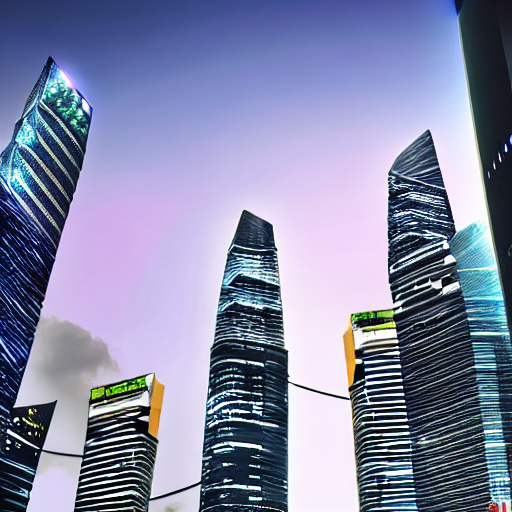

In [ ]:
# Generate an image
prompt = "A futuristic skyscraper in Singapore, digital art style"
image = pipe(prompt).images[0]

# View and save the result
image.save("singapore_future.png")
image


### **3.4 The Multimodal UI**

Finally, we reuse the **Gradio** skills from Phase 1 to build a "Text-to-Image" app. This allows a user to generate art without seeing a single line of code.

In [ ]:
import gradio as gr

def generate_image(prompt):
    # This function links the UI to the AI engine
    return pipe(prompt).images[0]

# Launch the visual interface
gr.Interface(
    fn=generate_image,
    inputs=gr.Textbox(label="Describe the image you want to create:"),
    outputs=gr.Image(label="AI-Generated Output"),
    title="🎨 Generative Art Studio"
).launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://699332323fb9c6bd12.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In our slides, we concluded our theory by looking at the **End-to-End AI Agent**—the stage where models move out of the development environment and into the user's hands.

---

## [Extension] Phase 4: Full Deployment (The Delivery Pillar)

### **The Bridge: From Theory to Build**

This is the "Grand Finale". An AI model is only a tool if it is accessible to its users. We are moving from **Isolated Code** to a **Live Production Agent**.

**In this Lab:** You are now applying **solution-architecture thinking**—the same approach used by professional AI engineers. You will wire your AI logic into a **Telegram Bot**, creating a system that "listens" for a user's request on a mobile device and "responds" with an AI-generated asset. The challenge here isn't just the AI math, but the **Engineering Logic** required to maintain a continuous service loop.

---

### **4.1 Secure Bot Configuration**

Just like our API keys, we must handle our **Telegram Bot Token** securely using `userdata`.

To get a Telegram Bot HTTP API token, search for "@BotFather" in the Telegram app, start a chat, and use the /newbot command. Follow the instructions to name your bot, and BotFather will provide the token needed to authenticate your bot.

**Steps to Get a New Token**
1.   Open Telegram and search for @BotFather (ensure it has a blue checkmark).
2.   Click Start and send the message /newbot.
3.   Choose a name for your bot.
4.   Create a unique username for your bot, which must end in "bot" (e.g., MyTest_bot).
5.   BotFather will send a message with the API token (a long string of letters and numbers).


*Note: Ensure you have your token from BotFather and have added it to your 'Secrets' (🔑) as `TELEGRAM_TOKEN`.*

In [ ]:
import requests
import time
from google.colab import userdata

# Configuration
TOKEN = userdata.get('TELEGRAM_TOKEN')
BASE_URL = f"https://api.telegram.org/bot{TOKEN}/"


### **4.2 The "Listener" Logic: Identifying the User**

Before we can send an image, our code needs to know who is talking to it. We use `getUpdates` to fetch the most recent message and the user's unique `chat_id`.

In [ ]:
# Initialize and fetch the latest chat info
response = requests.get(BASE_URL + 'getUpdates').json()

# Extract the Chat ID and the User's text
if response['result']:
    chat_id = response['result'][-1]['message']['chat']['id']
    print(f"Connected to Chat ID: {chat_id}")
else:
    print("Please send a message to your bot first!")


Connected to Chat ID: 7885384997


### **4.3 The "Responder" Loop: Connecting the Pipeline**

We will now start a `while True` loop. This keeps the script running, constantly checking for new prompts. When a prompt arrives, it triggers the **Stable Diffusion** engine from Phase 3 and sends the photo back to your phone.

**Control Note:** To stop the bot, type `exit` in Telegram or interrupt the cell via **Runtime → Interrupt execution**.

In [ ]:
import os

last_text = ""

print("Bot is now listening... Type 'exit' in Telegram to stop.")

while True:
    # 1. Check for new messages
    res = requests.get(BASE_URL + 'getUpdates').json()
    if not res['result']:
        continue

    current_text = res['result'][-1]['message']['text']

    # 2. Prevent duplicate processing
    if current_text != last_text:
        if current_text.lower() == "exit":
            print("Shutting down bot...")
            break

        # 3. Trigger the AI Engine
        print(f"Generating: {current_text}")
        requests.get(BASE_URL + f"sendMessage?chat_id={chat_id}&text=Processing your request...")

        # Generate the image using the pipe from Phase 3
        image = pipe(current_text).images[0]
        image_path = "bot_output.png"
        image.save(image_path)

        # 4. Send the asset back to the user
        with open(image_path, 'rb') as photo:
            files = {'photo': photo}
            requests.post(BASE_URL + f"sendPhoto?chat_id={chat_id}", files=files)

        last_text = current_text

    time.sleep(5) # Standard polling delay


Bot is now listening... Type 'exit' in Telegram to stop.
Generating: hello


  0%|          | 0/50 [00:00<?, ?it/s]

Generating: A cat


  0%|          | 0/50 [00:00<?, ?it/s]

KeyboardInterrupt: 

---

### **Reflecting on Your Build**

You have now successfully:

1. **Orchestrated** a high-speed cloud API.
2. **Governed** a local private model.
3. **Generated** visual assets from latent noise.
4. **Deployed** a live mobile agent.

**This consolidated notebook is now your toolkit.** You can reuse these phases to build private corporate search tools, regional language assistants, or automated creative studios.